

![nba park sdo](images/nba_park_sdo.png)

---

## From Intuition to Efficiency: A Data-Driven Approach to NBA Shot Selection

**Course:** Projekt Big Data  
**Professor:** Prof. Valentin Protschky  

**Team Members:**  
All members are students at the University of Applied Sciences Munich, pursuing a Bachelor of Science in Data Science & Scientific Computing.

- Melih Koc  
- Furkan Aksakal  
- Enes Yasaroglu  

---

## Table of Contents

1. [Introduction](#1-introduction)
   - [1.1 Project Context & Motivation](#11-project-context--motivation)
   - [1.2 Objective: The Shot Decision Optimizer](#12-objective-the-shot-decision-optimizer)
   - [1.3 Methodology Overview](#13-methodology-overview)

2. [Setup & Libraries](#2-setup--libraries)
   - [2.1 Importing Required Libraries](#21-importing-required-libraries)
   - [2.2 Environment Configuration](#22-environment-configuration)

3. [Data Loading](#3-data-loading)
   - [3.1 Accessing the NBA Stats API](#31-accessing-the-nba-stats-api)
   - [3.2 Loading ShotChartDetails](#32-loading-shotchartdetails)
   - [3.3 Loading Play-By-Play](#33-loading-play-by-play)
   - [NBA API Field Explanations](#nba-api-shot-chart-detail--field-explanations)

4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)
   - [4.1 Data Structure & Missing Values](#41-data-structure--missing-values)
   - [4.2 Distribution of Shots](#42-distribution-of-shots)
   - [4.3 Shot Distance Analysis](#43-shot-distance-analysis)
   - [4.4 Field Goal Percentage (FG%) Analysis](#44-field-goal-percentage-fg-analysis)
   - [4.5 Shot Locations (Hexbin & Heatmaps)](#45-shot-locations-hexbin--heatmaps)
   - [4.6 Distance Trends Across Seasons](#46-distance-trends-across-seasons)

5. [Feature Engineering](#5-feature-engineering)
   - [5.1 Geometric & Static Features](#51-geometric--static-features)
   - [5.2 Historical Player Features (Skill & Form)](#52-historical-player-features-skill--form)
   - [5.3 Context & Opponent Features](#53-context--opponent-features)
   - [5.4 Player Physical & Role Features](#54-player-physical--role-features)

6. [Training of the Models](#6-training-of-the-models)
   - [6.1 Machine Learning](#61-machine-learning)
     - [Loading Pre-trained Model](#611-loading-the-pre-trained-model)
     - [Model Comparison](#614-model-comparision)
     - [Model Conclusion](#615-model-conclusion-selecting-the-optimal-shot-decision-engine)
   - [6.2 Creating XGBoost predictions for Season 2024/25](#62-creating-xgboost-predictions-for-season-202425)

7. [Challenges with Modeling](#7-challenges-with-modeling)
   - [Model Limitation: Missing Context of Defense](#model-limitation-the-missing-context-of-defense)
   - [Case Study 1: The "Curry Paradox"](#case-study-1-the-curry-paradox)
   - [Case Study 2: The "Wemby Effect"](#case-study-2-the-wemby-effect--when-geometry-fails-to-see-size)

8. [Beyond Data: Understanding Randomness](#beyond-data-understanding-randomness-and-the-perfect-model)
   - [Case Study 3: The "Identical Twin" Shots](#case-study-3-the-identical-twin-shots--why-100-accuracy-is-impossible)

9. [Comparative Analysis & Conclusion](#comparative-analysis-validating-the-predictability-ceiling)
   - [Final Conclusion: Embracing the Variance](#final-conclusion-embracing-the-variance)

10. [Conclusion](#10-conclusion)
    - [Summary of Findings](#101-summary-of-findings)
    - [Limitations](#102-limitations)
    - [Next Steps](#103-next-steps)

10. [Minimum Viable Product - Streamlit App](#minimum-viable-product-streamlit-app)
    - [NBA Shot Decision Optimizer Login Interface](#nba-shot-decision-optimizer-login-interface)
    - [Season Game Dashboard](#season-game-dashboard)
    - [High Risk Shot Analysis](#high-risk-shot-analysis)
   

11. [Outlook](#11-outlook)
      - [Immediate Improvement: Incorporating Defensive Context](#1111-immediate-improvement-incorporating-defensive-context)
      - [Advanced Data & Feature Strategies](#1112-advanced-data--feature-strategies)
      - [Advanced Model Architectures](#1113-advanced-model-architectures)
      - [AI/ML Integration](#1121-aiml-integration)
      - [Cloud Computing](#1122-cloud-computing)

---

## 1. Introduction

---


### 1.1 Project Context & Motivation

*A season can hinge on one bad shot.*  
Throughout NBA history, poorly selected attempts in decisive moments have led to substantial sporting and financial consequences. Traditionally, shot selection has relied more on intuition, emotional momentum, or situational improvisation than on objective, data-driven reasoning.

While other sports have long embraced advanced metrics—such as **xG (Expected Goals)** in football or **WAR (Wins Above Replacement)** in baseball—basketball still lacks comparable real-time analytical depth. This project aims to help close that gap by shifting from static post-game heatmaps toward **predictive, context-aware analytics**.

---

### 1.2 Objective: The Shot Decision Optimizer

The purpose of this notebook is to develop a machine learning model that functions as a **Shot Decision Optimizer**.

By leveraging historical shot data, we estimate **xPTS (Expected Points)** for every potential attempt.  
This metric helps identify systematically low-value shots and supports improved decision-making—ultimately increasing a team's effective Field Goal Percentage (eFG%) through clearer, data-driven insight into shot quality.

---

### 1.3 Methodology Overview

To build this optimization framework, the notebook follows a structured workflow:

- **Data Basis:**  
  We use the **NBA Stats API**, providing a dataset of more than **200,000 shots per season**, combining Play-by-Play logs and ShotChartDetails.

- **Feature Engineering:**  
  Over 30 contextual and spatial features are processed, including XY-coordinates, shot clock status, and score differential.

- **Modeling:**  
  Two model families are employed:  
  - **Logistic Regression** for interpretability  
  - **XGBoost** for modeling complex non-linear patterns  

This analysis represents the backend foundation for an interactive dashboard aimed at providing actionable insights for analysts, coaches, and players.

---

## 2. Setup & Libraries

---

### 2.1 Importing Required Libraries

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

import seaborn as sns
from pathlib import Path
import sys
sys.path.append("../utils")
import eda_utils
import feature_engineering_utils
import load_data_utils
import logreg_modeling_utils
import xg_boost_modeling_utils
import warnings

---

### 2.2 Environment Configuration

In [2]:
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

FIGURES_DIR = Path("../figures/eda")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

---

## 3. Data Loading

---

### 3.1 Accessing the NBA Stats API

**Data Acquisition**

We used the `nba_api` to retrieve the raw data necessary for this project. The complete extraction process is implemented in the notebook `load_data_from_api`.

> **Note:** Please be aware that executing this notebook takes a significant amount of time due to the volume of data and API rate limits.

---

### 3.2 Loading ShotChartDetails

In [3]:
shot_data = eda_utils.load_data(file_path="../data/raw/nba_raw_shot_data.parquet")

---

### 3.3 Loading Play-By-Play

In [4]:
pbp_data = eda_utils.load_data(file_path="../data/raw/nba_raw_pbp_data.parquet")

---

## NBA API: Shot Chart Detail – Field Explanations

Below is a detailed description of the columns of the NBA *ShotChartDetail* endpoint. These explanations are based on the nba_api documentation. 

| Column | Description |
|---|---|
| **GRID_TYPE** | Indicates the kind of data grid used for shot chart aggregation (e.g., “Shot Chart Detail”). |
| **GAME_ID** | Unique identifier for the game (e.g., “0021500002”). |
| **GAME_EVENT_ID** | The event number in the game’s play-by-play log corresponding to the shot attempt. |
| **PLAYER_ID** | Unique identifier for the player who attempted the shot. |
| **PLAYER_NAME** | Full name of the player. |
| **TEAM_ID** | Unique identifier for the team of the shooter. |
| **TEAM_NAME** | Name of the team (e.g., “Golden State Warriors”). |
| **PERIOD** | Quarter or overtime period in which the shot was taken (1 = 1st quarter, etc.). |
| **MINUTES_REMAINING** | Minutes left in the current period when the shot was attempted. |
| **SECONDS_REMAINING** | Seconds left in the current minute when the shot was attempted. |
| **EVENT_TYPE** | Indicates the type of shot event. In the Shot Chart Detail dataset, this is always a shot attempt, either made or missed. |
| **ACTION_TYPE** | More granular description of the shot action, such as “Jump Shot”, “Layup”, “Dunk”, etc. |
| **SHOT_TYPE** | The shot category from an outcome perspective, usually “2PT Field Goal” or “3PT Field Goal”. |
| **SHOT_ZONE_BASIC** | Broad spatial classification of the shot location, e.g. “In the Paint (Non-RA)”, “Mid-Range”, “Above the Break 3” etc. |
| **SHOT_ZONE_AREA** | More specific area within the basic zone, such as “Left Side Center”, “Right Side Center”, etc. |
| **SHOT_ZONE_RANGE** | Distance-based zone category, e.g. “Less Than 8 ft”, “16-24 ft”, “24+ ft”. |
| **SHOT_DISTANCE** | Numeric distance (in feet) from the basket where the shot was taken. |
| **LOC_X** | X-coordinate of the shot on the court (relative to basket center). |
| **LOC_Y** | Y-coordinate of the shot on the court (relative to basket center). |
| **SHOT_ATTEMPTED_FLAG** | Binary flag (0/1) – indicates whether a shot was attempted (always 1). |
| **SHOT_MADE_FLAG** | Binary flag (0/1) – indicates whether the shot was made (1 = made, 0 = missed). |
| **GAME_DATE** | Date of the game when the shot was taken. |
| **HTM** | The home team’s abbreviation or ID in that game. (“Home Team Marker”) |
| **VTM** | The away team’s abbreviation or ID in that game. (“Visiting Team Marker”) |
| **PLAYER_SEASON_FG_PCT** | The player's field goal percentage for the season. *(added later.)*|
| **PLAYER_HEIGHT_CM** | The player’s height in cm. *(added later.)* |
| **PLAYER_POSITION** | The player’s official position by the NBA (e.g. Guard). *(added later.)* |
| **SEASON** | The NBA season in which the shot occurred (e.g., “2023-24”). |

---

## 4. Exploratory Data Analysis (EDA)

---

### 4.1 Data Structure & Missing Values

---

#### Shape & Memory Usage Overview

In [5]:
eda_utils.summarize_data(shot_data)

DATAFRAME OVERVIEW SUMMARY


,Rows,Columns,Memory (MB)
0,1293360,25,1286.9



Total rows: 1.293.360
Total memory usage: 1286.90 MB


---

#### Detailed Exploration

In [6]:
eda_utils.explore_data(shot_data)


Column Information:


,Column,Data Type,Non-Null Count,Null Count,Null %
0,GRID_TYPE,object,1293360,0,0.0
1,GAME_ID,object,1293360,0,0.0
2,GAME_EVENT_ID,int64,1293360,0,0.0
3,PLAYER_ID,int64,1293360,0,0.0
4,PLAYER_NAME,object,1293360,0,0.0
5,TEAM_ID,int64,1293360,0,0.0
6,TEAM_NAME,object,1293360,0,0.0
7,PERIOD,int64,1293360,0,0.0
8,MINUTES_REMAINING,int64,1293360,0,0.0
9,SECONDS_REMAINING,int64,1293360,0,0.0



First 3 Rows:


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,Shot Chart Detail,0021900001,7,1628366,Lonzo Ball,1610612740,New Orleans Pelicans,1,11,48,Missed Shot,Driving Floating Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),8-16 ft.,11,2,114,1,0,20191022,TOR,NOP,2019-20
1,Shot Chart Detail,0021900001,9,202324,Derrick Favors,1610612740,New Orleans Pelicans,1,11,47,Made Shot,Tip Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,0,0,-6,1,1,20191022,TOR,NOP,2019-20
2,Shot Chart Detail,0021900001,10,1628384,OG Anunoby,1610612761,Toronto Raptors,1,11,29,Missed Shot,Driving Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,15,28,1,0,20191022,TOR,NOP,2019-20



Last 3 Rows:


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
1293357,Shot Chart Detail,0022500268,662,1642862,Liam McNeeley,1610612766,Charlotte Hornets,4,1,17,Made Shot,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,26,119,239,1,1,20251122,CHA,LAC,2025-26
1293358,Shot Chart Detail,0022500268,664,1642353,Cam Christie,1610612746,LA Clippers,4,0,56,Missed Shot,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,25,104,235,1,0,20251122,CHA,LAC,2025-26
1293359,Shot Chart Detail,0022500268,672,1629012,Collin Sexton,1610612766,Charlotte Hornets,4,0,25,Made Shot,Running Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,-1,33,1,1,20251122,CHA,LAC,2025-26



5 Random Sample Rows:


,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
736598,Shot Chart Detail,0022200799,50,1630227,Daishen Nix,1610612745,Houston Rockets,1,8,14,Missed Shot,Jump Shot,3PT Field Goal,Right Corner 3,Right Side(R),24+ ft.,23,234,-11,1,0,20230204,OKC,HOU,2022-23
476042,Shot Chart Detail,0022100550,444,1629026,Kenrich Williams,1610612760,Oklahoma City Thunder,3,0,23,Missed Shot,Jump Shot,3PT Field Goal,Right Corner 3,Right Side(R),24+ ft.,23,235,5,1,0,20220102,OKC,DAL,2021-22
668638,Shot Chart Detail,0022200413,665,2544,LeBron James,1610612747,Los Angeles Lakers,5,0,48,Made Shot,Driving Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,1,10,10,1,1,20221213,LAL,BOS,2022-23
1204396,Shot Chart Detail,0022400967,539,1626145,Tyus Jones,1610612756,Phoenix Suns,4,7,51,Made Shot,Jump Shot,3PT Field Goal,Left Corner 3,Left Side(L),24+ ft.,24,-232,70,1,1,20250314,PHX,SAC,2024-25
764950,Shot Chart Detail,0022200960,465,1629003,Shake Milton,1610612755,Philadelphia 76ers,3,0,0,Missed Shot,Jump Shot,3PT Field Goal,Backcourt,Back Court(BC),Back Court Shot,56,152,540,1,0,20230304,MIL,PHI,2022-23


---

#### Datetype Column Transformation

In [7]:
shot_data["GAME_DATE"] = pd.to_datetime(shot_data["GAME_DATE"])

---

#### Duplicate Analysis

In [8]:
eda_utils.summarize_duplicates(shot_data)

DUPLICATE RECORDS SUMMARY


,Total Rows,Duplicate Rows,Duplicate %
0,1293360,0,0.0


---

#### Datatypes and Statistics

In [9]:
eda_utils.summarize_data_types_and_stats(shot_data)


Numeric columns (11): ['GAME_EVENT_ID', 'PLAYER_ID', 'TEAM_ID', 'PERIOD', 'MINUTES_REMAINING', 'SECONDS_REMAINING', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG']
Datetime columns (1): ['GAME_DATE']
Categorical columns (13): ['GRID_TYPE', 'GAME_ID', 'PLAYER_NAME', 'TEAM_NAME', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'HTM', 'VTM', 'SEASON']

Checking for potential issues in numeric columns:


,Column,Count,Unique Count,Min,Max,Contains Negative?,Zero Count
0,GAME_EVENT_ID,1293360,895,3,956,False,0
1,PLAYER_ID,1293360,1121,1713,1643141,False,0
2,TEAM_ID,1293360,30,1610612737,1610612766,False,0
3,PERIOD,1293360,7,1,7,False,0
4,MINUTES_REMAINING,1293360,13,0,12,False,125398
5,SECONDS_REMAINING,1293360,60,0,59,False,34228
6,SHOT_DISTANCE,1293360,89,0,88,False,96636
7,LOC_X,1293360,501,-250,250,True,53111
8,LOC_Y,1293360,856,-52,878,True,41858
9,SHOT_ATTEMPTED_FLAG,1293360,1,1,1,False,0



Datetime Column Summary:


,Column,Min Date,Max Date,Range (Days),Missing Values
0,GAME_DATE,2019-10-22,2025-11-22,2223,0



Categorical Column Summary:


,Column,Count,Unique Count,Top Value 1,Top Value 1 Count
0,GRID_TYPE,1293360,1,Shot Chart Detail,1293360
1,GAME_ID,1293360,7295,0022401189,234
2,PLAYER_NAME,1293360,1122,Jayson Tatum,8558
3,TEAM_NAME,1293360,30,Memphis Grizzlies,44868
4,EVENT_TYPE,1293360,2,Missed Shot,688574
5,ACTION_TYPE,1293360,48,Jump Shot,403739
6,SHOT_TYPE,1293360,2,2PT Field Goal,779151
7,SHOT_ZONE_BASIC,1293360,7,Above the Break 3,384810
8,SHOT_ZONE_AREA,1293360,6,Center(C),731661
9,SHOT_ZONE_RANGE,1293360,5,Less Than 8 ft.,526394


---

#### Outlier Analysis

In [10]:
eda_utils.detect_outliers_iqr(shot_data)

Detecting outliers using IQR (1.5 × IQR rule)

Outlier Summary:


,Column,Outlier_Count,Outlier_Percent,Lower_Bound,Upper_Bound
0,GAME_EVENT_ID,0,0.00,-3.520000e+02,1.000000e+03
1,PLAYER_ID,0,0.00,-1.934762e+06,3.768346e+06
2,TEAM_ID,0,0.00,1.610613e+09,1.610613e+09
3,PERIOD,30,0.00,-2.000000e+00,6.000000e+00
4,MINUTES_REMAINING,0,0.00,-7.000000e+00,1.700000e+01
5,SECONDS_REMAINING,0,0.00,-3.100000e+01,8.900000e+01
6,SHOT_DISTANCE,729,0.06,-3.000000e+01,5.800000e+01
7,LOC_X,201042,15.54,-1.900000e+02,1.860000e+02
8,LOC_Y,2250,0.17,-2.410000e+02,4.390000e+02
9,SHOT_ATTEMPTED_FLAG,0,0.00,1.000000e+00,1.000000e+00


---

### 4.2 Distribution of Shots

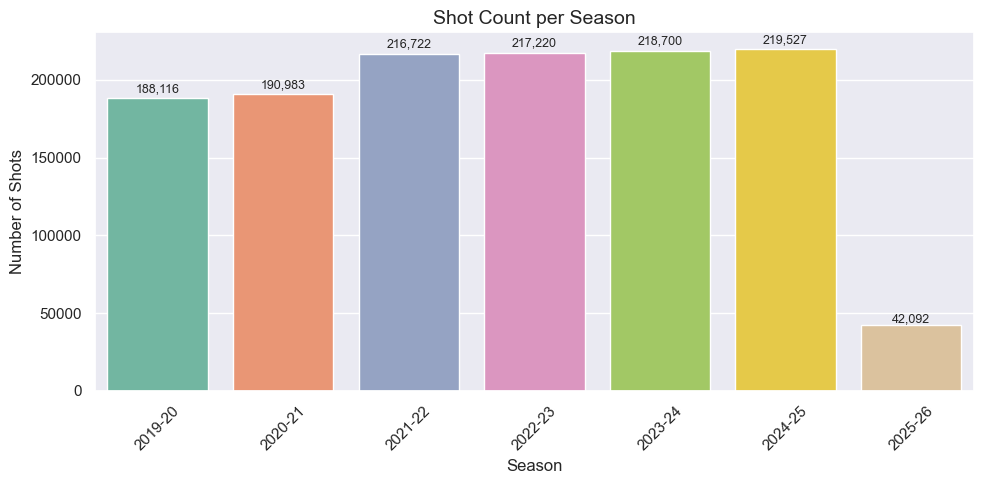

In [11]:
eda_utils.plot_shot_count_per_season(shot_data)

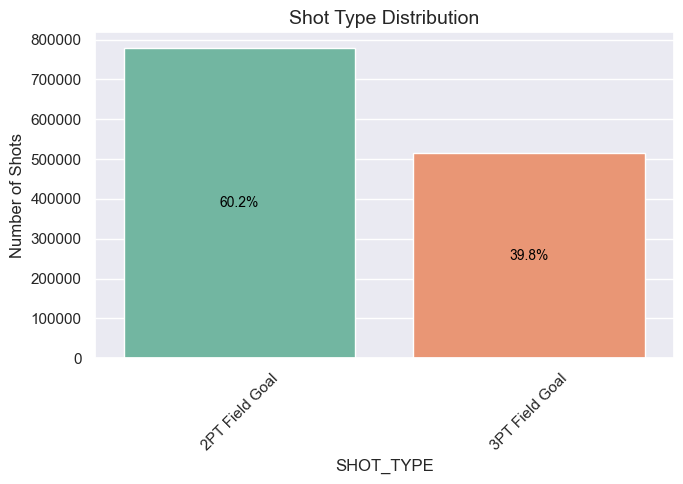

In [12]:
eda_utils.plot_shot_type_distribution(shot_data)

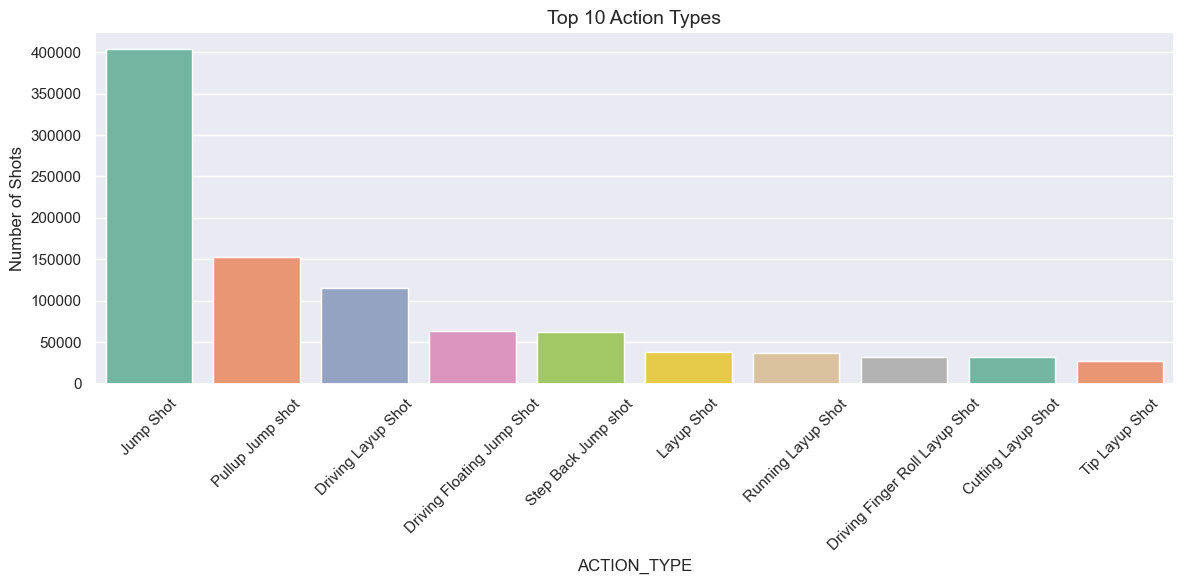

In [13]:
eda_utils.plot_top_action_types(shot_data)

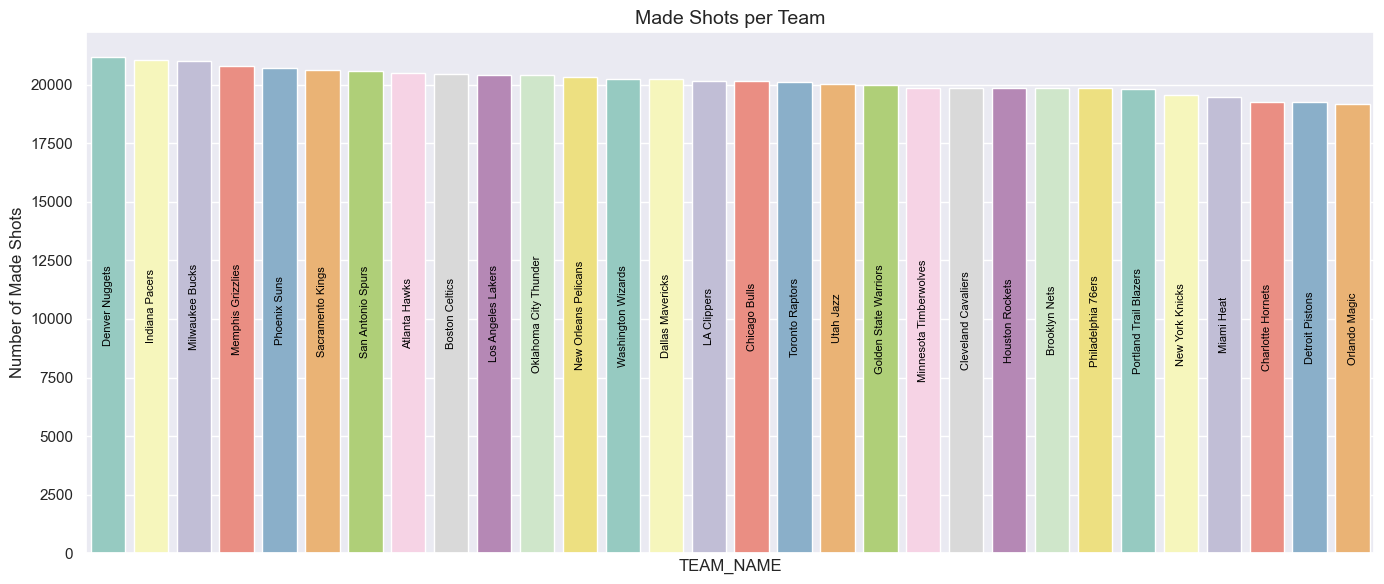

In [14]:
eda_utils.plot_made_shots_per_team(shot_data)

---

### 4.3 Shot Distance Analysis

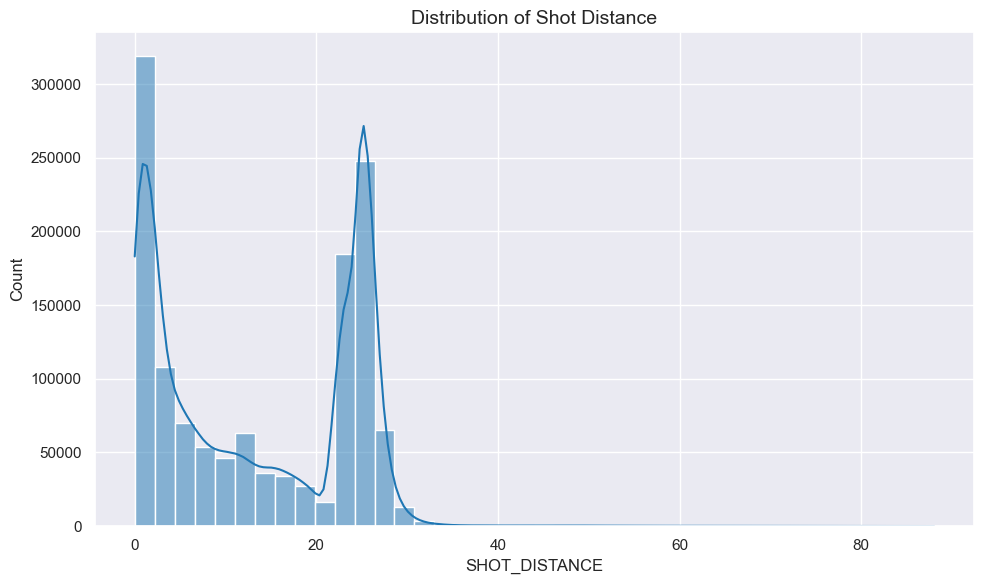

In [15]:
eda_utils.plot_shot_distance_hist(shot_data)

Modern NBA offenses prioritize high-efficiency shots; either at the rim or from beyond the arc while mid-range attempts have steadily declined in frequency.

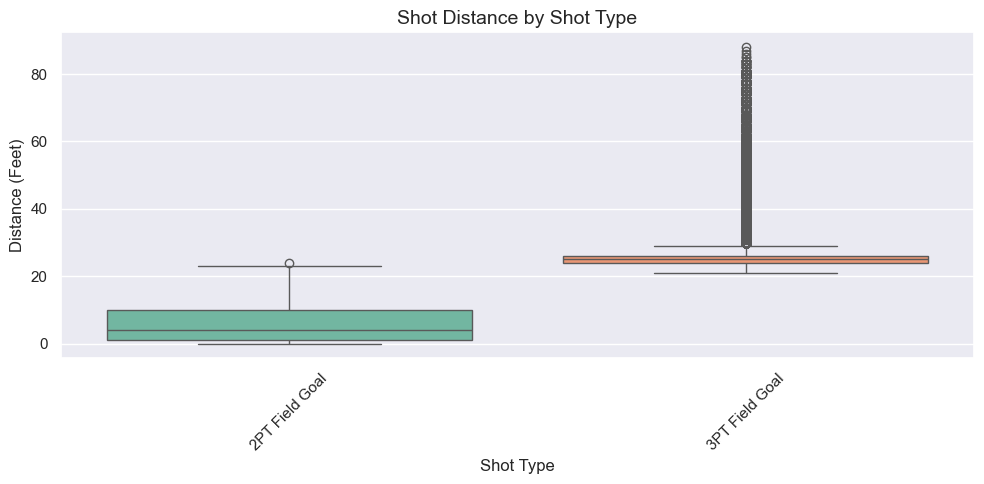

In [16]:
eda_utils.plot_shot_distance_by_type(shot_data)

#### Shot Distance Distribution by Shot Type

* **2PT Field Goals** show a **wide spread** of distances: the median sits around **4 ft** (paint touches), but the IQR stretches from the rim to about **10 ft**, and whiskers approach **22 ft**, reflecting a mix of paint finishes and mid-range pull-ups. Limited by the 3PT line.
* **3PT Field Goals** are densely grouped just outside the arc (typically **24–26 ft**), with minimal distance variation—the IQR remains tight, highlighting consistent spacing. Only a few attempts are from beyond 30 ft, usually as last-second heaves before the buzzer.

-> 2PT shots range from close-range layups to deep mid-range attempts, while 3PT shots are typically intentional and tightly clustered in distance near the arc.


---

### 4.4 Field Goal Percentage (FG%) Analysis

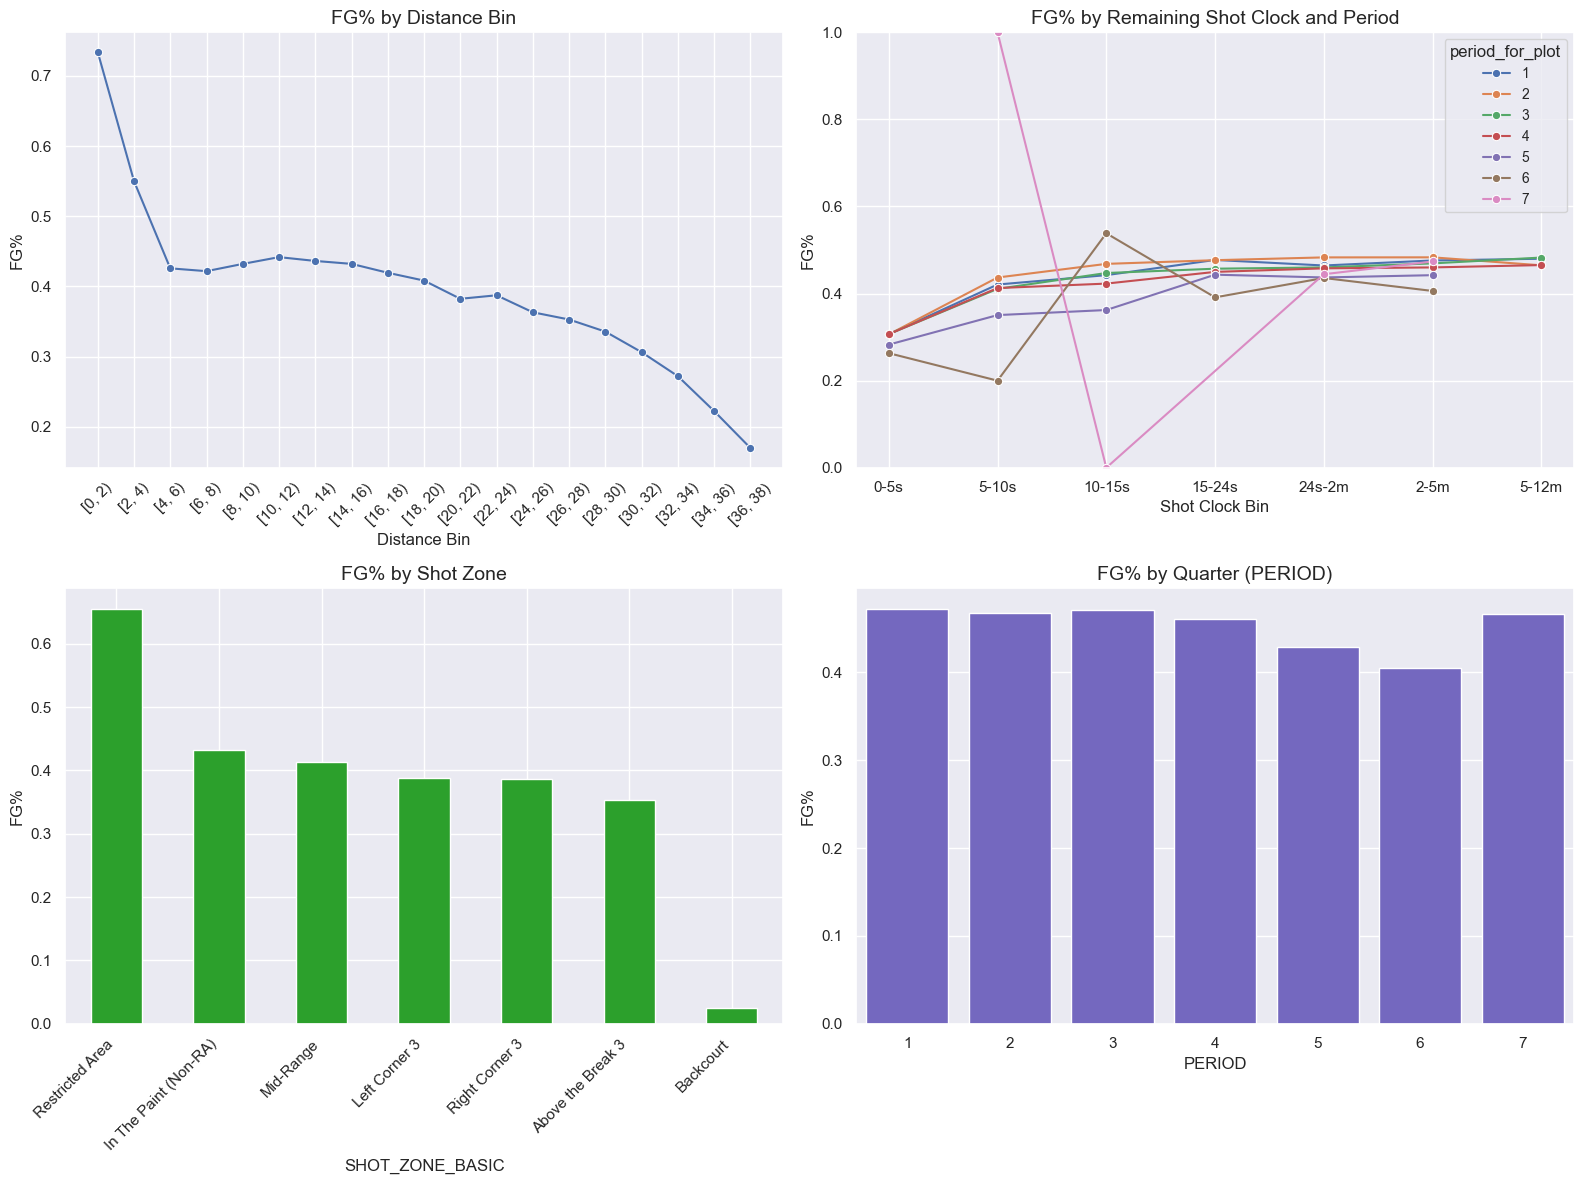

In [17]:
# 2x2 Figure erstellen
fig, axes = plt.subplots(2, 2, figsize=(16,12))
ax1, ax2, ax3, ax4 = axes.flatten()

# Die FG%-Plots auf die Subplots zeichnen
eda_utils.plot_shot_distance_fg(shot_data, ax=ax1)   # FG% nach Distanz
eda_utils.plot_time_pressure(shot_data, ax=ax2)     # FG% nach Time Pressure
eda_utils.plot_zone_efficiency(shot_data, ax=ax3)    # FG% nach Zone
eda_utils.plot_period_effect(shot_data, ax=ax4)      # FG% nach Period

# Layout anpassen
plt.tight_layout()
plt.show()

#### FG% by Distance Bin
* **Rim shots (0–2 ft)** convert at the highest rate (≈ 73%).
* There’s a steep dropoff on “short twos” (2–4 ft → ~ 55%), then a leveling around ~ 42–45% from 6–18 ft.
* Beyond ~18 ft, efficiency declines steadily, ending under 20% at 36–39 ft.
* This reinforces the premium on rim proximity and the penalty for long-distance attempts.



#### FG% by Remaining Shot Clock and Period
* Across most periods (1–4,6), FG% **rises** from the first 5 sec (~30%) to the 10–15 sec window (~45–50%), then plateaus around ~45–48% for the rest of the clock.
* Early-clock (0–5 sec) makes are lowest—reflecting hurried, highly contested or transition attempts.
* Late-clock consistency suggests teams settle into their offense before the final 10 sec.
* Be aware: Period 7 (triple overtime) shows fluctuating FG% due to a tiny sample size—only a handful of games reach this point.



#### FG% by Shot Zone
* As expected, shots in the **restricted area** dominate in efficiency.
* Paint-area twos (non-RA) are ~43%, outperforming all threes.
* **Corner threes** (~39%) are slightly more efficient than above-break threes (~36%).


#### FG% by Period (Including OT)
* Quarters 1–4 hover around ~46–47%.
* Efficiency dips in the first two OTs (Periods 5–6), likely from fatigue or higher‐pressure looks.
* Period 7 rebounds, but that bin is very small.



---

### 4.5 Shot Locations (Hexbin & Heatmaps)

---

In [18]:
PLAYERS_OF_INTEREST = [
    "LeBron James",
    "Stephen Curry",
    "James Harden",
    "Kevin Durant",
    "Paul George",
    "Nikola Jokic"
]

# Filter to available players
available_players = [
    p for p in PLAYERS_OF_INTEREST 
    if p in shot_data['PLAYER_NAME'].values
]

TEAM_NAMES = sorted(shot_data['TEAM_NAME'].unique())
SEASONS = sorted(shot_data['SEASON'].unique())

print(f"Available players: {available_players}")
print(f"Available teams: {len(TEAM_NAMES)}")
print(f"Available seasons: {SEASONS}")

Available players: ['LeBron James', 'Stephen Curry', 'James Harden', 'Kevin Durant', 'Paul George']
Available teams: 30
Available seasons: ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


In [19]:
# Dropdown for players
player_dropdown = eda_utils.Dropdown(
    options=available_players,
    description='Player:',
    style={'description_width': '120px'}
)

# Multi-select for seasons
season_select = eda_utils.SelectMultiple(
    options=SEASONS,
    value=[SEASONS[-1]],  # Default: last season
    description='Seasons:',
    rows=3,
    style={'description_width': '120px'}
)

# Output for plot
output_shot_chart = eda_utils.Output()

def update_shot_chart(player, seasons):
    """Update shot chart based on widget values."""
    with output_shot_chart:
        output_shot_chart.clear_output(wait=True)
        if not seasons:
            print("Please select at least one season.")
        else:
            fig = eda_utils.plot_hex_shot_chart(shot_data, player, list(seasons))
            fig.show()

# Widget observers
player_dropdown.observe(
    lambda change: update_shot_chart(player_dropdown.value, season_select.value),
    names='value'
)
season_select.observe(
    lambda change: update_shot_chart(player_dropdown.value, season_select.value),
    names='value'
)

# Layout for shot chart
shot_chart_controls = eda_utils.VBox([
    eda_utils.HBox([player_dropdown, season_select]),
    output_shot_chart
])

print("SHOT CHART")
shot_chart_controls

SHOT CHART


In [20]:
update_shot_chart(player_dropdown.value, season_select.value)

In [21]:
# Dropdown for teams
team_dropdown = eda_utils.Dropdown(
    options=TEAM_NAMES,
    description='Team:',
    style={'description_width': '120px'}
)

# Dropdown for season
season_dropdown = eda_utils.Dropdown(
    options=SEASONS,
    value=SEASONS[-1],  # Default: last season
    description='Season:',
    style={'description_width': '120px'}
)

# Output for PPP plot
output_ppp_heatmap = eda_utils.Output()

def update_ppp_heatmap(team, season):
    """Update PPP heatmap based on widget values."""
    with output_ppp_heatmap:
        output_ppp_heatmap.clear_output(wait=True)
        ppp_matrix = eda_utils.ecalculate_ppp(shot_data, team, season, top_n=10)
        fig = eda_utils.plot_ppp_heatmap(ppp_matrix, team, season)
        fig.show()

# Widget observers
team_dropdown.observe(
    lambda change: update_ppp_heatmap(team_dropdown.value, season_dropdown.value),
    names='value'
)
season_dropdown.observe(
    lambda change: update_ppp_heatmap(team_dropdown.value, season_dropdown.value),
    names='value'
)

# Layout for PPP heatmap
ppp_controls = eda_utils.VBox([
    eda_utils.HBox([team_dropdown, season_dropdown]),
    output_ppp_heatmap
])

print("PPP HEATMAP")
ppp_controls

PPP HEATMAP


In [22]:
update_ppp_heatmap(team_dropdown.value, season_dropdown.value)

---

### 4.6 Distance Trends Across Seasons

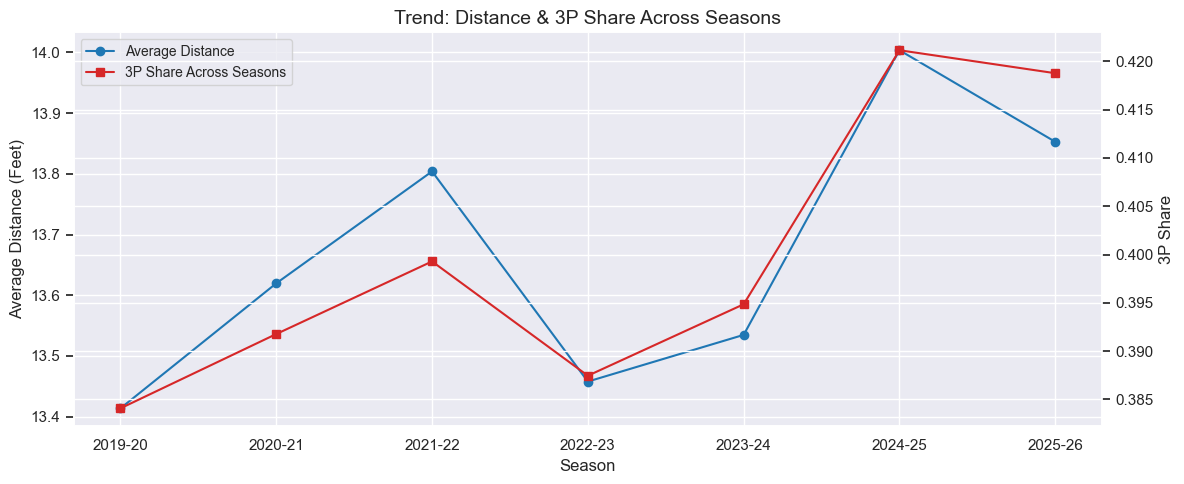

In [23]:
eda_utils.plot_season_trends(shot_data)

#### League Evolution: Shot Distance & 3-Point Emphasis

* The parallel rise in **average shot distance** and **3-point share** through 2021-22 reflects teams leaning into floor spacing and valuing the extra point, pushing lineups to stretch defenses.
* The brief dip in 2022-23 suggests a tactical recalibration—perhaps defenses adapted or pace slowed—temporarily pulling shots closer after Corona.
* The strong rebound to a 14-ft average and 42% 3-point rate in 2024-25 underscores that modern offenses doubled down on perimeter volume.

---

## 5. Feature Engineering

---

### 5.1 Geometric & Static Features 

These features describe the physical nature of the shot and the current game state.


---

#### **CUSTOM_SHOT_ZONE**

In [24]:
shot_data = feature_engineering_utils.create_custom_shot_zone(shot_data)

- **Description:** A highly granular division of the court that combines distance and direction.
- **Calculation:** Concatenation of the broad zone (`SHOT_ZONE_BASIC`) and the specific area (`SHOT_ZONE_AREA`).
- **Example:** "Mid-Range | Left Side(L)"
- **Interpretation:** This creates a "spatial signature." While a player might be average at mid-range shots in general, they might have a "sweet spot" on the left side. This allows the model to map individual player efficiency to specific locations on the floor.

![custom shot zone plot](images/custom_shot_zone_plot.png)


---

#### **SHOT_ANGLE**

In [25]:
shot_data = feature_engineering_utils.calculate_shot_angle(shot_data)

- **Description:** The angle of the shooter relative to the basket (in degrees).
- **Calculation:** `arctan2(LOC_X, LOC_Y)` converted to degrees. We use the absolute value because left and right are geometrically equivalent for the model.
  - 0° = Directly in front of the basket (Center).
  - ≈90° = Corners (Baseline).
- **Example:** 88.5
- **Interpretation:** This helps the model understand the "sightline" to the basket. Shots from the side (90°) have a different perspective and often a different distance than shots from the front (0°). It allows the model to learn which angles are statistically more difficult to convert.

---

#### **SHOT_VALUE**

In [26]:
shot_data = feature_engineering_utils.calculate_shot_value(shot_data)

- **Description:** The potential point value assigned to the shot.
- **Calculation:** If the text "3PT" appears in the shot type → 3, otherwise 2.
- **Example:** 3
- **Interpretation:** Crucial for calculating **Expected Points (xPts)**. By understanding the value, the model can help determine if a lower-probability 3-pointer is strategically "better" than a higher-probability 2-pointer based on the potential reward.

---

#### **TIME_REMAINING**

In [27]:
shot_data = feature_engineering_utils.calculate_time_remaining(shot_data)

- **Description:** The total time remaining in the current quarter in seconds.
- **Calculation:** `MINUTES_REMAINING * 60 + SECONDS_REMAINING`.
- **Example:** 125.0
- **Interpretation:** This captures the "urgency" of the game. Very low values often indicate "Buzzer Beaters" or rushed shots taken as the clock expires. The model uses this to account for the drop in shot quality that typically occurs at the end of a period.

---

### 5.2 Historical Player Features (Skill & Form)

These features evaluate the shooter's skill level and current form.

---

#### **PLAYER_SEASON_FG_PCT**

In [28]:
shot_data = feature_engineering_utils.calculate_player_season_fg(shot_data)

- **Description:** The player's general shooting percentage for the current season up to the current game.
- **Calculation:** `(Cumulative Makes) / (Cumulative Attempts)`. Resets at the start of a new season.
- **Example:** 0.455
- **Interpretation:** This acts as the "baseline skill" indicator. A shot taken by a historically accurate 50% shooter has a higher base probability of going in than a shot by a 35% shooter, regardless of the location.

---

#### **PLAYER_ZONE_FG_PCT**

In [29]:
shot_data = feature_engineering_utils.calculate_player_zone_fg(shot_data)

- **Description:** The player's shooting percentage specifically in the current `CUSTOM_SHOT_ZONE`.
- **Calculation:** Rolling average of the last 50 shots taken in this specific zone.
- **Example:** 0.320 (for zone "Left Corner 3")
- **Interpretation:** This identifies "spatial mastery." Even elite players have "cold spots" on the floor. This feature tells the model exactly how dangerous a specific player is from a specific location, smoothing out their general season average with local data.

---

#### **LAST_5_SHOTS_MADE (Hot Hand)**

In [30]:
shot_data = feature_engineering_utils.calculate_hot_hand(shot_data)

- **Description:** An indicator of short-term momentum or "rhythm."
- **Calculation:** Sum of makes in the last 5 shots (regardless of location).
- **Example:** 4.0
- **Interpretation:** This tests the "Hot Hand" theory. A player who has made 4 of their last 5 shots is often in a "flow state" or has high confidence. The model uses this to see if recent success predicts the outcome of the current shot.

---

#### **PLAYER_LAST_100_FG_PCT (Long-Term Form)**

In [31]:
shot_data = feature_engineering_utils.calculate_long_term_form(shot_data)

- **Description:** The medium-to-long-term form curve of the player.
- **Calculation:** Average shooting percentage over the last 100 shots.
- **Example:** 0.480
- **Interpretation:** This tracks a player's "form." Unlike the "Hot Hand" (which covers minutes), this covers weeks. It helps the model distinguish between a temporary "slump" and a "peak," providing a more stable view of the player's recent consistency.

---

### 5.3 Context & Opponent Features

These features describe the external circumstances of the shot.

---

#### **OPP_DEF_STRENGTH (Opponent Defense)**

In [32]:
shot_data = feature_engineering_utils.add_team_abbreviations(shot_data)

shot_data = feature_engineering_utils.identify_opponent(shot_data)

shot_data = feature_engineering_utils.calculate_opponent_def_strength(shot_data)

- **Description:** A rating of how effective the opposing team's defense is at stopping shots.
- **Calculation:** The shooting percentage the opponent allows on average (Rolling average of the last 500 shots against them).
- **Example:** 0.485 (Weak Defense) vs. 0.430 (Strong Defense)
- **Interpretation:** Not all shots are contested equally. A shot against a top-tier defensive team is much harder to make than a shot against a struggling defense. This feature acts as a "difficulty modifier" based on the opponent's defensive quality.

---

#### **SHOT_CLOCK**

In [33]:
feature_engineering_utils.calculate_shot_clock_from_pbp('../data/raw/nba_raw_pbp_data.parquet', '../data/processed/nba_pbp_with_shot_clock.parquet')

Loading data from: ../data/raw/nba_raw_pbp_data.parquet ...
Converting game clock (Vectorized)...
Calculating shot clock (Vectorized)...
Calculation completed.
Saving as ../data/processed/nba_pbp_with_shot_clock.parquet...


,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,SEASON,GAME_ID,quarter_remaining,shotclock_remaining
0,0021900001,2,PT12M00.00S,1,0,,0,,,0,0,0,,0,0,0,0,,Start of 1st Period (8:04 PM EST),period,start,0,0,1,2019-20,0021900001,720.0,<NA>
1,0021900001,4,PT12M00.00S,1,1610612761,TOR,201188,Gasol,M. Gasol,0,0,0,,0,,,0,h,Jump Ball Gasol vs. Favors: Tip to Ball,Jump Ball,,1,0,2,2019-20,0021900001,720.0,<NA>
2,0021900001,7,PT11M48.00S,1,1610612740,NOP,1628366,Ball,L. Ball,2,114,11,Missed,1,,,0,v,MISS Ball 11' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,3,2019-20,0021900001,708.0,12.0
3,0021900001,8,PT11M47.00S,1,1610612740,NOP,202324,Favors,D. Favors,0,0,0,,0,,,0,v,Favors REBOUND (Off:1 Def:0),Rebound,Unknown,1,0,4,2019-20,0021900001,707.0,<NA>
4,0021900001,9,PT11M47.00S,1,1610612740,NOP,202324,Favors,D. Favors,0,-6,1,Made,1,0,2,2,v,Favors 1' Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,5,2019-20,0021900001,707.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3396587,0022401230,722,PT00M05.00S,4,1610612760,OKC,1628983,Gilgeous-Alexander,S. Gilgeous-Alexander,0,0,0,,0,110,96,206,h,Gilgeous-Alexander Free Throw 1 of 2 (31 PTS),Free Throw,Free Throw 1 of 2,1,0,526,2024-25,0022401230,5.0,<NA>
3396588,0022401230,723,PT00M05.00S,4,1610612760,OKC,1628983,Gilgeous-Alexander,S. Gilgeous-Alexander,0,0,0,,0,111,96,207,h,Gilgeous-Alexander Free Throw 2 of 2 (32 PTS),Free Throw,Free Throw 2 of 2,1,0,527,2024-25,0022401230,5.0,<NA>
3396589,0022401230,724,PT00M00.00S,4,1610612745,HOU,1630224,Green,J. Green,-218,132,25,Missed,1,,,0,v,MISS Ja. Green 25' 3PT Pullup Jump Shot,Missed Shot,Pullup Jump shot,1,3,528,2024-25,0022401230,0.0,0.0
3396590,0022401230,725,PT00M00.00S,4,0,,1610612745,,,0,0,0,,0,,,0,v,Rockets Rebound,Rebound,Unknown,0,0,529,2024-25,0022401230,0.0,<NA>


In [34]:
shot_data = feature_engineering_utils.merge_shot_clock(shot_data, '../data/processed/nba_pbp_with_shot_clock.parquet')

Merging Shot Clock Data...
Removed 172818 duplicate rows from shotclock data to prevent row explosion.
Shotclock Merge Match Rate: 94.8%


- **Description:** The time remaining on the 24-second shot clock when the shot was taken.
- **Calculation:** This feature is derived from raw Play-by-Play data using a possession-tracking logic:
    1. **Time Parsing:** The game clock (e.g., "PT10M30S") is converted into total seconds remaining in the quarter.
    2. **Possession Detection:** We identify when a team takes control of the ball by looking for changes in the `teamId` from the previous event.
    3. **Elapsed Time:** For every event, we calculate the time elapsed since the start of that possession (`Possession Start Time - Current Time`).
    4. **Formula:** `Shot Clock = 24.0s - Elapsed Time`.
    5. **Adjustment:** We clip the result between 0 and 24 seconds and ensure it never exceeds the total time left in the quarter.
- **Example:** 3.2
- **Interpretation:** A primary indicator of pressure.
  - **Low Value (< 4s):** High-pressure "broken plays" where the shooter is forced to rush, typically leading to a lower success rate.
  - **High Value (> 15s):** Often indicates a "transition" play or an open shot created early in the possession, typically leading to higher success rates.

---

### 5.4 Player Physical & Role Features

These features capture the static characteristics of the shooter, defining their physical advantages and designated role within the team structure.

---

#### **PLAYER_HEIGHT_CM**

In [35]:
shot_data = feature_engineering_utils.add_player_height(shot_data, '../data/raw/nba_raw_player_data.csv')

Loading player height info from: ../data/raw/nba_raw_player_data.csv ...
Merging Player Height...
Player Height added. Match Rate: 100.0%


- **Description:** The player's physical height represented as a numeric integer value (in centimeters).
- **Calculation:** Converted from the standard "feet-inches" string format. Formula: ((feet×12)+inches)×2.54, rounded to the nearest whole number.
- **Example:** A height of "6-6" becomes 198.
- **Interpretation:** Taller players generally have a higher release point, making their shots harder to block. Unlike a string category, this numeric value allows the model to understand physical scale and learn linear relationships (e.g., height differential).

---

#### **PLAYER_POSITION**

In [36]:
shot_data = feature_engineering_utils.add_player_position(shot_data, '../data/raw/nba_raw_player_data.csv')

Loading player position info from: ../data/raw/nba_raw_player_data.csv ...
Merging Player Position...
Player Position added. Match Rate: 100.0%


- **Description:** The official designated role of the player on the roster.
- **Calculation:** Extracted directly from the player's static profile metadata.
- **Example:** "Guard", "Center", "Forward-Center".
- **Interpretation:** Provides context for shot selection and expected efficiency. A shot taken in the paint is routine for a Center but might be a drive in traffic for a Guard. This helps the model normalize shot difficulty based on the player's specific role on the court.

---

In [37]:
shot_data.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON,CUSTOM_SHOT_ZONE,SHOT_ANGLE,SHOT_VALUE,TIME_REMAINING,PLAYER_SEASON_FG_PCT,PLAYER_ZONE_FG_PCT,LAST_5_SHOTS_MADE,PLAYER_LAST_100_FG_PCT,TEAM_ABBREVIATION,OPPONENT_TEAM,OPP_DEF_STRENGTH,SHOTCLOCK,PLAYER_HEIGHT_CM,PLAYER_POSITION
0,Shot Chart Detail,0021900001,7,1628366,Lonzo Ball,1610612740,New Orleans Pelicans,1,11,48,Missed Shot,Driving Floating Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),8-16 ft.,11,2,114,1,0,2019-10-22,TOR,NOP,2019-20,In The Paint (Non-RA) | Center(C),1.005086,2,708,NaN,NaN,0.0,NaN,NOP,TOR,NaN,12.0,196,Guard
1,Shot Chart Detail,0021900001,9,202324,Derrick Favors,1610612740,New Orleans Pelicans,1,11,47,Made Shot,Tip Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,0,0,-6,1,1,2019-10-22,TOR,NOP,2019-20,Restricted Area | Center(C),180.000000,2,707,NaN,NaN,0.0,NaN,NOP,TOR,NaN,11.0,206,Forward
2,Shot Chart Detail,0021900001,10,1628384,OG Anunoby,1610612761,Toronto Raptors,1,11,29,Missed Shot,Driving Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,15,28,1,0,2019-10-22,TOR,NOP,2019-20,Restricted Area | Center(C),28.178590,2,689,NaN,NaN,0.0,NaN,TOR,NOP,NaN,6.0,201,Forward-Guard
3,Shot Chart Detail,0021900001,12,201950,Jrue Holiday,1610612740,New Orleans Pelicans,1,11,16,Missed Shot,Driving Finger Roll Layup Shot,2PT Field Goal,Mid-Range,Right Side(R),8-16 ft.,8,81,-1,1,0,2019-10-22,TOR,NOP,2019-20,Mid-Range | Right Side(R),90.707319,2,676,NaN,NaN,0.0,NaN,NOP,TOR,NaN,11.0,193,Guard
4,Shot Chart Detail,0021900001,14,200768,Kyle Lowry,1610612761,Toronto Raptors,1,11,11,Missed Shot,Running Pull-Up Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,25,178,176,1,0,2019-10-22,TOR,NOP,2019-20,Above the Break 3 | Right Side Center(RC),45.323702,3,671,NaN,NaN,0.0,NaN,TOR,NOP,NaN,19.0,183,Guard


In [38]:
shot_data.to_parquet("../data/processed/nba_processed_shot_data.parquet", index=False)

# 6. Training of the Models

In this stage, we implement and compare two different modeling approaches to predict shot outcomes: a **Logistic Regression** model and an **XGBoost** model.

> **Note:** This section provides a brief summary of the model training process and initial results. For detailed exploratory data analysis, hyperparameter tuning, and comprehensive documentation, please refer to the dedicated notebooks created for each specific model.

In [39]:
# 1. Clean the data (removing metadata and leakage columns like EVENT_TYPE)
# This ensures the model learns patterns, not just 'cheats'
df_model = logreg_modeling_utils.clean_data_for_training(shot_data)

# 2. Split the data chronologically
# We define X_test and y_test here as the shared foundation for all models
SPLIT_SEASON = '2024-25'
X_train, y_train, X_test, y_test = logreg_modeling_utils.split_data_by_season(
    df_model,
    split_season=SPLIT_SEASON
)

Splitting data. Split Season: 2024-25
Train Set Seasons: ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24'] (1031741 shots)
Test Set Seasons:  ['2024-25', '2025-26'] (261619 shots)


## 6.1 Machine Learning

In this section, we apply our optimized model to the dataset. The primary goal is to calculate the probability of a shot being made ($P(\text{Make})$) and derive the **Expected Points ($xPts$)**.

> **Note:** For a deep dive into the model's training process, cross-validation, and extensive statistical evaluation, please refer to the specialized notebook: `logistic_reg_modeling.ipynb` or `xg_boost_modeling.ipynb`.

### 6.1.1 Loading the Pre-trained Model
Instead of retraining the model, we load the optimized pipeline (including scaling and encoding) from our previous training session.

In [40]:
MODEL_PATH = '../models/nba_logreg_model.joblib'

model_log_reg = joblib.load(MODEL_PATH)

# Alternatively, you can load the XGBoost model:

# MODEL_PATH = '../models/nba_xgb_model.joblib'
# model_xgb = joblib.load(MODEL_PATH)

### 6.1.2 Generating Predictions and $xPts$
We now use the model to predict probabilities for our test set. We then calculate the $xPts$ by multiplying the probability by the shot's point value (2 or 3).

In [41]:
# 1. Predict probabilities for the 'Made' class (index 1)
y_probs = model_log_reg.predict_proba(X_test)[:, 1]

# 2. Create the Evaluation DataFrame (df_eval)
df_eval_log_reg = X_test.copy()

# 3. Attach predictions and actual results
df_eval_log_reg['PROBABILITY_MAKE'] = y_probs
df_eval_log_reg['SHOT_MADE_FLAG'] = y_test

# 4. Restore metadata from the original dataframe for analysis
meta_cols = ['GAME_ID', 'GAME_EVENT_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 'SHOT_TYPE', 'SEASON', 'LOC_X', 'LOC_Y']
df_eval_log_reg = df_eval_log_reg.join(shot_data[meta_cols], how='left')

# 5. Calculate Expected Points (xPts)
df_eval_log_reg['xPts'] = df_eval_log_reg['PROBABILITY_MAKE'] * df_eval_log_reg['SHOT_VALUE']

print("df_eval created with xPts calculations.")
df_eval_log_reg[['PLAYER_NAME', 'SHOT_TYPE', 'PROBABILITY_MAKE', 'xPts']].head()

df_eval created with xPts calculations.


,PLAYER_NAME,SHOT_TYPE,PROBABILITY_MAKE,xPts
1042565,Naz Reid,2PT Field Goal,0.544152,1.088304
1042559,Rui Hachimura,2PT Field Goal,0.409803,0.819606
1042564,Jaxson Hayes,2PT Field Goal,0.874046,1.748092
1042563,D'Angelo Russell,2PT Field Goal,0.513304,1.026608
1042562,Naz Reid,2PT Field Goal,0.556106,1.112211


### 6.1.3 Model Logic & Feature Interpretation
The models have been trained to recognize the "structural" quality of a shot. Based on the coefficients, we can interpret how the model evaluates different features:

* **Dominance of Action Types:** The model's logic is primarily driven by the **Action Type**. High-percentage actions like Dunks and Alley Oops have the strongest positive impact on probability.
* **Distance as a Predictor:** `SHOT_DISTANCE` remains the most significant negative factor. The model correctly learned that as distance increases, the probability of scoring decreases significantly.
* **Geography vs. Position:** Interestingly, the model prioritizes **where** and **how** a shot is taken over the player's official position. `PLAYER_POSITION` was not a top influencer, suggesting that a Dunk is high-value regardless of whether a Guard or Center finishes it.
* **The "Heat Check" Factor:** The model detected a slight negative impact for players on a "hot streak" (`LAST_5_SHOTS_MADE`), reflecting that overconfidence often leads to more difficult shot selection.

### 6.1.4 Model Comparision

<table style="width:80%">
  <tr>
    <td style="width:50%; text-align:center;">
      <img src="./images/logReg_Game_Validation.png" alt="LogReg" style="width:100%">
      <br><em>Logistic Regression Validation</em>
    </td>
    <td style="width:50%; text-align:center;">
      <img src="./images/xgBoost_Game_Validation.png" alt="XGBoost" style="width:100%">
      <br><em>XGBoost Validation</em>
    </td>
  </tr>
</table>

Across game-level aggregation, Logistic Regression marginally outperforms XGBoost, with lower MAE (8.84 vs. 9.05), lower MSE, and a higher R² (0.205 vs. 0.164), indicating better alignment between summed xPts and actual team scores. This suggests that the linear model’s bias toward additive, stable effects aggregates more cleanly across possessions, whereas XGBoost’s non-linear shot-level patterns introduce additional variance that does not cancel out at the game level.

<table style="width:80%">
  <tr>
    <td style="width:50%; text-align:center;">
      <img src="./images/logReg_Calibration.png" alt="LogReg" style="width:100%">
      <br><em>Logistic Regression Calibration</em>
    </td>
    <td style="width:50%; text-align:center;">
      <img src="./images/xgBoost_Calibration.png" alt="XGBoost" style="width:100%">
      <br><em>XGBoost Calibration</em>
    </td>
  </tr>
</table>

XGBoost demonstrates marginally better calibration in aggregate, achieving lower Brier scores than Logistic Regression for all shots (0.2228 vs. 0.226) as well as for both two-pointers (0.2183 vs. 0.2235) and three-pointers (0.2289 vs. 0.2295). However, this numerical advantage comes with noticeably higher instability in the reliability curve for three-point shots, where XGBoost exhibits sharp fluctuations at mid-to-high predicted probabilities. This pattern suggests that the tree-based model leverages complex interactions to push probabilities toward extremes, but limited data support for specific three-point contexts leads to unreliable bin-level calibration. Logistic Regression, while slightly worse in Brier score, produces smoother and more monotonic calibration curves, reflecting stronger bias toward global shot averages. In a basketball context, this trade-off is expected: three-point outcomes are inherently noisy, and the linear model’s conservatism better reflects that irreducible uncertainty, whereas XGBoost’s confidence gains are fragile in low-sample regions.


<table style="width:50%">
  <tr>
    <td style="width:50%; text-align:center;">
      <img src="./images/logReg_Model_Metrics.png" alt="LogReg" style="width:100%">
      <br><em>Logistic Regression Model Metrics</em>
    </td>
    <td style="width:50%; text-align:center;">
      <img src="./images/xgBoost_Model_Metrics.png" alt="XGBoost" style="width:100%">
      <br><em>XGBoost Model Metrics</em>
    </td>
  </tr>
</table>

XGBoost achieves a modest but consistent improvement over Logistic Regression, with higher ROC–AUC (0.6686 vs. 0.6545) and accuracy (0.6326 vs. 0.6282), indicating better overall discrimination between made and missed shots. This gain is driven primarily by improved precision on made shots (class 1: 0.69 vs. 0.67), suggesting that XGBoost is more effective at identifying high-quality shot contexts through non-linear interactions (e.g. shooter, location, and shot type). However, recall for made shots remains low across models (~0.40–0.41), highlighting the inherent randomness of shooting outcomes and the difficulty of confidently flagging makes in a noisy environment. Logistic Regression compensates with slightly more balanced behavior and stronger recall for misses, reflecting its bias toward dominant global patterns.


### 6.1.5 Model Conclusion: Selecting the Optimal Shot Decision Engine


For a model to serve as a **shot decision optimizer**, it must reliably distinguish high- from low-quality shot opportunities and produce accurate probability estimates for computing **expected points (xPTS)**. Based on the empirical results, **XGBoost** is the preferred model for shot-level decision-making, despite Logistic Regression’s advantages in stability and aggregation.

---

#### Predictive Performance and Discrimination

* **XGBoost** achieves stronger discriminatory power, with higher **ROC–AUC (0.6686 vs. 0.6545)** and **accuracy (0.6326 vs. 0.6282)**.
* It also delivers higher **precision for made shots (0.69 vs. 0.67)**, indicating more effective identification of genuinely high-quality shot contexts driven by non-linear feature interactions.

#### Probability Calibration and xPTS Estimation

* **XGBoost** attains lower **Brier scores** across all shot types **all shots (0.2228)**, **two-pointers (0.2183)**, and **three-pointers (0.2289)**, reflecting more accurate probabilistic estimates.
* This improved calibration directly translates into more reliable **xPTS calculations**, which are essential for evaluating shot value and guiding on court decision making.

#### Stability versus Expressiveness

* **Logistic Regression** exhibits superior stability when predictions are aggregated at the game level, as reflected by a higher **R² (0.205 vs. 0.164)**.
* However, for shot-level optimization, **XGBoost’s** ability to model complex context dependent interactions, provides greater practical value.

#### **Final Verdict:** 
**Logistic Regression is better suited for stable, aggregate score prediction, but **XGBoost is the stronger choice as a shot decision optimizer**. Its superior discrimination and more accurate xPTS estimates make it better aligned with the goal of improving shot selection and, ultimately, offensive efficiency.**


## 6.2 Creating XGBoost predictions for Season 2024/25

We now generate a Parquet file containing shot-level predicted make probabilities produced by our trained XGBoost model for the 2024/25 season.

The output file (../data/processed/xgboost_preds_2024-25.parquet) stores the predicted probabilities together with relevant metadata (player, game, location, shot value, timestamps, and video URLs). This Parquet file will be consumed by the Streamlit app to power interactive visualizations and decision-support features.



In [42]:
# 1) Paths
MODEL_PATH = "../models/nba_xgboost_model.joblib"
DATA_PATH = "../data/processed/nba_processed_shot_data.parquet"
SEASON = "2024-25"

# 2) Load model and data
model = joblib.load(MODEL_PATH)
df_all = pd.read_parquet(DATA_PATH)

# 3) Filter season and create feature matrix compatible with model
df_season = df_all[df_all["SEASON"] == SEASON].copy()
# clean_data_for_training should return the feature matrix used by the pipeline
X = xg_boost_modeling_utils.clean_data_for_training(df_season)

# ensure indices align to original rows kept
X = X.loc[X.index.intersection(df_season.index)]
df_meta = df_season.loc[X.index].copy()

# 4) Predict probabilities (class 1 = made)
probs = model.predict_proba(X)[:, 1]

# 5) Build output dataframe with requested columns (map PCT -> PTC naming)
out = pd.DataFrame(index=X.index)
out["TEAM_NAME"] = df_meta.get("TEAM_NAME")
out["PERIOD"] = df_meta.get("PERIOD")
out["ACTION_TYPE"] = df_meta.get("ACTION_TYPE")
out["SHOT_DISTANCE"] = df_meta.get("SHOT_DISTANCE")
out["LOC_X"] = df_meta.get("LOC_X")
out["LOC_Y"] = df_meta.get("LOC_Y")
out["PLAYER_SEASON_FG_PTC"] = df_meta.get("PLAYER_SEASON_FG_PCT")
out["SEASON"] = df_meta.get("SEASON")
out["CUSTOM_SHOT_ZONE"] = df_meta.get("CUSTOM_SHOT_ZONE")
out["SHOT_VALUE"] = df_meta.get("SHOT_VALUE")
out["SHOT_ANGLE"] = df_meta.get("SHOT_ANGLE")
out["TIME_REMAINING"] = df_meta.get("TIME_REMAINING")
out["PLAYER_ZONE_FG_PTC"] = df_meta.get("PLAYER_ZONE_FG_PCT")
out["LAST_5_SHOTS_MADE"] = df_meta.get("LAST_5_SHOTS_MADE")
out["OPP_DEF_STRENGTH"] = df_meta.get("OPP_DEF_STRENGTH")
out["SHOTCLOCK"] = df_meta.get("SHOTCLOCK")
out["predicted_shot_probability"] = probs
out["TEAM_ID"] = df_meta.get("TEAM_ID")
out["GAME_EVENT_ID"] = df_meta.get("GAME_EVENT_ID")
out["PLAYER_NAME"] = df_meta.get("PLAYER_NAME")
out["PLAYER_ID"] = df_meta.get("PLAYER_ID")
out["GAME_ID"] = df_meta.get("GAME_ID")
out["HTM"] = df_meta.get("HTM")
out["VTM"] = df_meta.get("VTM")
out["SHOT_MADE_FLAG"] = df_meta.get("SHOT_MADE_FLAG")
out["MINUTES_REMAINING"] = df_meta.get("MINUTES_REMAINING")
out["SECONDS_REMAINING"] = df_meta.get("SECONDS_REMAINING")

# 6) Build video_url
BASE_URL = (
    "https://www.nba.com/stats/events"
    "?CFID=&CFPARAMS=&GameEventID={GameEventID}&GameID={GameID}&Season={Season}&flag=1"
)
out["video_url"] = out.apply(
    lambda r: BASE_URL.format(GameEventID=int(r["GAME_EVENT_ID"]) if pd.notna(r["GAME_EVENT_ID"]) else "",
                              GameID=r["GAME_ID"] if pd.notna(r["GAME_ID"]) else "",
                              Season=r["SEASON"] if pd.notna(r["SEASON"]) else ""),
    axis=1
)

# 7) Reorder columns
required_cols = [
    "TEAM_NAME","PERIOD","ACTION_TYPE","SHOT_DISTANCE","LOC_X","LOC_Y",
    "PLAYER_SEASON_FG_PTC","SEASON","CUSTOM_SHOT_ZONE","SHOT_VALUE","SHOT_ANGLE","TIME_REMAINING",
    "PLAYER_ZONE_FG_PTC","LAST_5_SHOTS_MADE","OPP_DEF_STRENGTH","SHOTCLOCK",
    "predicted_shot_probability","TEAM_ID","GAME_EVENT_ID","PLAYER_NAME",
    "PLAYER_ID","GAME_ID","HTM","VTM","SHOT_MADE_FLAG","MINUTES_REMAINING",
    "SECONDS_REMAINING","video_url"
]
out = out.reindex(columns=[c for c in required_cols if c in out.columns])

# 8) Save or return — ensure predict directory exists
PREDICT_DIR = "../data/predict"
os.makedirs(PREDICT_DIR, exist_ok=True)

output_path = os.path.join(PREDICT_DIR, "xgboost_preds_2024-25.parquet")
out.to_parquet(output_path, index=True)

# 7. Challenges with Modeling

## Model Limitation: The Missing Context of Defense


While our model provides valuable insights into shooting efficiency using the NBA API, it is crucial to understand its current architectural boundaries. Specifically, the model lacks **defender-proximity data**, which leads to a significant "blind spot" in predicting Expected Points ($xPts$).

## **Case Study 1:** The "Curry Paradox"
To understand this problem, let's look at a moment from the **2024 Paris Olympics Gold Medal Game** featuring Stephen Curry.

* **The Situation:** Stephen Curry (one of the best shooters ever) is being guarded by **two defenders at once**. He is trapped.
* **The Better Option:** Two of his teammates (LeBron James and Kevin Durant) are standing completely alone and could take an easy shot.

![curry dagger](images/curry_dagger.png)

* **The Reality:** Despite being "double-teamed," Curry takes the shot anyway and scores. Any coach would normally say: "Pass the ball to the open man!"

### Why the Model "Fails" Here
If we feed this play into our model, it gets confused:
1. **Hidden Difficulty:** The model sees Curry at his favorite spot and thinks: "High chance of scoring!" It doesn't know that four hands are in his face, making the shot nearly impossible for a normal player.
2. **Missing Choices:** The model doesn't realize that passing would have been the "smarter" statistical play. It only evaluates the shot that *was* taken, not the better options that were ignored.

**The Lesson:** Our model calculates "Shot Quality if Open," but it cannot account for the pressure of elite defense.

---

## **Case Study 2:** The "Wemby Effect" – When Geometry Fails to See Size

This second case study focuses on a specific play from our NBA dataset where the model produces a highly misleading $xPts$ value due to the absence of defensive context.

### The Case: Santi Aldama vs. Victor Wembanyama
In this play from the 2024-25 season, Grizzlies' player Santi Aldama attempts a shot at the rim.

* **The Visual Context:** As seen in the image below, Aldama is attempting a shot directly in the path of Victor Wembanyama—one of the league's most elite rim protectors.

![Wemby Block Context](images/wemby_block.png)

* **The Outcome:** Wembanyama's length and timing lead to a clinical block. [Watch the NBA Stats Video here](https://www.nba.com/stats/events?CFID=&CFPARAMS=&GameEventID=176&GameID=0022400567&Season=2024-25&flag=1&title=MISS%20Aldama%208%27%20Jump%20Shot).

### Model Output vs. Reality
When we look at the model's prediction for this specific event using our calculation `wemby[["PROBABILITY_MAKE", "xPts"]]`, we see the following:

In [43]:
wemby_block = df_eval_log_reg[(df_eval_log_reg["GAME_ID"] == '0022400567') & (df_eval_log_reg["GAME_EVENT_ID"] == 168)]
wemby_block[["ACTION_TYPE", "PROBABILITY_MAKE", "xPts"]]

,ACTION_TYPE,PROBABILITY_MAKE,xPts
1132383,Dunk Shot,0.863709,1.727418


**The Issue:**
* **Overestimation:** The model predicts a massive **86.4% make probability**, resulting in **1.73 xPts**. In basketball terms, a shot with 1.73 expected points is considered an "absolute must-take" and one of the most efficient shots possible.
* **The Dunk Influence:** Our Feature Importance analysis revealed that **Dunk Shots** have the highest positive impact on the model's coefficients. Since the model identifies this action as a high-value dunk/layup attempt at close range (8 feet), it automatically assigns a near-certain success rate.
* **Contextual Blindness:** The model only sees the high-value "Action Type" and the short distance. It does **not** know that the "human eraser" Victor Wembanyama is standing between the shooter and the basket.

### Why this is a "Weak Point"
This example perfectly mirrors the Curry case study but with even more extreme data:
1.  **Elite Rim Protection:** Without "Defender ID" or "Distance to nearest Defender" as a feature, the model treats a layup against an empty rim the same as a layup against a 7'4" shot-blocker.
2.  **Action over Reality:** The model assumes that because a shot is a Dunk/Layup from 8 feet, it has a high success rate based on league averages. It fails to adjust for the individual defensive gravity of elite players like Wembanyama.

**Conclusion:** To improve the model, we would need to integrate **Second Spectrum tracking data** (defender proximity) to discount the $xPts$ when an elite defender is within a 2-3 foot radius of the shooter.

---

# 8. Beyond Data: Understanding Randomness and the "Perfect" Model

While the previous examples focused on missing defender information, this section explores a different challenge: **Inherent Variance**. In sports, even if we had every bit of data in the world, some things remain unpredictable.

---

## **Case Study 3:** The "Identical Twin" Shots – Why 100% Accuracy is Impossible

In data science, we always strive for high accuracy. However, in basketball, even a "perfect" model can never reach 100% precision. This is because of the **inherent randomness** (variance) of the game.

### The Experiment: Finding "Twin" Shots
To prove this, we used follwing script to find two shots by Stephen Curry that are almost identical in our dataset:
* **Same Player:** Stephen Curry.
* **Same Shot Type:** Pull-up 3-pointer.
* **Same Location:** Almost the exact same coordinates on the court.
* **Same Context:** Similar movement and timing.

In [44]:
# =========================
# 1) Filter: Stephen Curry Pull-up 3s (Center, Above the Break)
# =========================
curry = shot_data[
    (shot_data["PLAYER_ID"] == 201939) &
    (shot_data["CUSTOM_SHOT_ZONE"] == "Above the Break 3 | Center(C)") &
    (shot_data["ACTION_TYPE"] == "Pullup Jump shot")
].copy()

# Keep only relevant columns
curry = curry[
    ["LOC_X", "LOC_Y", "SHOT_MADE_FLAG", "GAME_ID", "GAME_EVENT_ID", "SEASON"]
].dropna()

# =========================
# 2) Separate made and missed shots
# =========================
made = curry[curry["SHOT_MADE_FLAG"] == 1]
missed = curry[curry["SHOT_MADE_FLAG"] == 0]

# =========================
# 3) Create shot pairs + compute Euclidean distance
# =========================
pairs = []

for _, m in made.iterrows():
    for _, mi in missed.iterrows():
        dist = np.sqrt(
            (m["LOC_X"] - mi["LOC_X"])**2 +
            (m["LOC_Y"] - mi["LOC_Y"])**2
        )
        pairs.append({
            "made_x": m["LOC_X"],
            "made_y": m["LOC_Y"],
            "miss_x": mi["LOC_X"],
            "miss_y": mi["LOC_Y"],
            "distance": dist,
            "made_game_id": m["GAME_ID"],
            "made_event_id": m["GAME_EVENT_ID"],
            "miss_game_id": mi["GAME_ID"],
            "miss_event_id": mi["GAME_EVENT_ID"],
            "miss_season": mi["SEASON"],
            "made_season": m["SEASON"]
        })

pairs_df = pd.DataFrame(pairs)

# =========================
# 4) Generate NBA event URLs
# =========================
BASE_URL = (
    "https://www.nba.com/stats/events"
    "?CFID=&CFPARAMS=&GameEventID={event_id}"
    "&GameID={game_id}"
    "&Season={season}"
    "&flag=1"
)

pairs_df["made_url"] = pairs_df.apply(
    lambda r: BASE_URL.format(
        event_id=r["made_event_id"],
        game_id=r["made_game_id"],
        season=r["made_season"]
    ),
    axis=1
)

pairs_df["miss_url"] = pairs_df.apply(
    lambda r: BASE_URL.format(
        event_id=r["miss_event_id"],
        game_id=r["miss_game_id"],
        season=r["miss_season"]
    ),
    axis=1
)

# =========================
# 5) Best pair (smallest distance)
# =========================
best_pair = pairs_df.sort_values("distance").iloc[0]

print("Distance:", best_pair["distance"])
print("Made shot URL:", best_pair["made_url"])
print("Missed shot URL:", best_pair["miss_url"])

# =========================
# 6) Filter very similar shots (e.g. distance < 10)
# =========================
close_pairs = pairs_df[pairs_df["distance"] < 10]

# Display the top 5 most similar shot pairs
close_pairs.sort_values("distance").head()

Distance: 0.0
Made shot URL: https://www.nba.com/stats/events?CFID=&CFPARAMS=&GameEventID=189&GameID=0022400492&Season=2024-25&flag=1
Missed shot URL: https://www.nba.com/stats/events?CFID=&CFPARAMS=&GameEventID=330&GameID=0022400101&Season=2024-25&flag=1


,made_x,made_y,miss_x,miss_y,distance,made_game_id,made_event_id,miss_game_id,miss_event_id,miss_season,made_season,made_url,miss_url
32341,7,299,7,299,0.0,0022400508,337,0022400366,422,2024-25,2024-25,https://www.nba.com/stats/events?CFID=&CFPARAM...,https://www.nba.com/stats/events?CFID=&CFPARAM...
32080,16,306,16,306,0.0,0022400492,189,0022400101,330,2024-25,2024-25,https://www.nba.com/stats/events?CFID=&CFPARAM...,https://www.nba.com/stats/events?CFID=&CFPARAM...
1611,18,277,18,277,0.0,0022000116,330,0022100837,553,2021-22,2020-21,https://www.nba.com/stats/events?CFID=&CFPARAM...,https://www.nba.com/stats/events?CFID=&CFPARAM...
36075,-21,263,-21,263,0.0,0022500006,642,0022200996,634,2022-23,2025-26,https://www.nba.com/stats/events?CFID=&CFPARAM...,https://www.nba.com/stats/events?CFID=&CFPARAM...
21799,-5,275,-5,275,0.0,0022201187,257,0022201025,495,2022-23,2022-23,https://www.nba.com/stats/events?CFID=&CFPARAM...,https://www.nba.com/stats/events?CFID=&CFPARAM...


### One goes In, one stays Out
Despite having nearly identical starting conditions, the outcomes are completely different. This highlights the "luck" or "noise" factor that no model can fully capture:
* **The Make:** [Watch Curry score from this spot](https://www.nba.com/stats/events?CFID=&CFPARAMS=&GameEventID=189&GameID=0022400492&Season=2024-25&flag=1)
* **The Miss:** [Watch Curry miss from the exact same spot](https://www.nba.com/stats/events?CFID=&CFPARAMS=&GameEventID=330&GameID=0022400101&Season=2024-25&flag=1)

#### Model Comparison: Same Input, Different Outcomes

Here is how the Logistic Regression model evaluated these two specific shots. Despite one being a make and one being a miss, the model correctly assigned them almost identical probabilities:

In [45]:
curry_shot = df_eval_log_reg[((df_eval_log_reg["GAME_ID"] == '0022400492') & (df_eval_log_reg["GAME_EVENT_ID"] == 189)) | ((df_eval_log_reg["GAME_ID"] == '0022400101') & (df_eval_log_reg["GAME_EVENT_ID"] == 330))]
curry_shot[["ACTION_TYPE", "LOC_Y", "LOC_X", "PROBABILITY_MAKE", "xPts"]]

,ACTION_TYPE,LOC_Y,LOC_X,PROBABILITY_MAKE,xPts
1049487,Pullup Jump shot,306,16,0.309566,0.928698
1118966,Pullup Jump shot,306,16,0.328762,0.986285


### Why this matters for our Model

1.  **The Human Factor (The "Noise"):**
    Even the best shooter in the world isn't a robot. A tiny difference in the flick of the wrist, a millisecond in release timing, or even a slight change in focus can alter the outcome. Since our data cannot measure these microscopic physical details, the model sees two "identical" inputs but two "different" outputs.

2.  **The "Glass Ceiling" for Evaluation:**
    Because of this randomness, a model that predicts 100% or even 90% accuracy would actually be **overfitting**. It would be trying to predict "luck," which is impossible. In sports analytics, we accept that there is a limit to how much we can predict.

3.  **Outcome vs. Decision:**
    This is exactly why we build this model! We don't want to predict the future with 100% certainty. Instead, we want to find shots where the **probability of success was high**, even if the ball didn't go in.
    * If a player misses a shot that had an 80% $xPts$ chance, it was still a **great decision**.
    * Our tool helps coaches reward **good decisions**, not just **lucky outcomes**.

**Conclusion:** Success in basketball is a mix of skill, context, and a bit of "noise." Our model filters out the noise to focus on the skill and the quality of the decision. This explains why our evaluation metrics (like Precision or Recall) will never be perfect—and they shouldn't be.

# 9. Comparative Analysis: Validating the "Predictability Ceiling"

To put our results into perspective, we compared our model's performance with established benchmarks from the data science community and academic research. Our finding—that shot prediction has a natural "glass ceiling"—is consistently mirrored in other high-level projects.

### **Stanford University Research (Brett Meehan)**
In his research paper ["Predicting NBA Shots"](https://cs229.stanford.edu/proj2017/final-reports/5132133.pdf), Brett Meehan from Stanford University examined various machine learning algorithms. His findings strongly support our observations:
* **The Accuracy Benchmark:** Meehan found that while random guessing yields 50%, the most ambitious benchmark achieved in the field is approximately 68% accuracy using XGBoost.
* **Model Comparisons:** His research showed that Random Forests reached about 61%, while Logistic Regression achieved 59%, which aligns  more or less with the performance ranges we observed.
* **The Complexity of Human Movement:** Meehan notes that reaching 90-95% accuracy is unrealistic because standard box-score features cannot capture "noise" such as a player being slightly off-balance or having an elbow out of place during the shot.

### **Adrian Chmielewski’s Analysis**
Similarly, the project by [Adrian Chmielewski](https://adrian-chmielewski.com/nba-shot-success-prediction/) utilizes advanced feature engineering to predict shot outcomes. His results also converge in the mid-to-high 60% range. This independent validation confirms that our results are not limited by our model's architecture, but rather by the inherent randomness of the sport itself.

---

## **Final Conclusion: Embracing the Variance**

The fact that our project, the Stanford research, and Chmielewski’s implementation all settle around the **60-68% accuracy mark** is a critical validation of our work. 

As we demonstrated in **Case Study 3**, the remaining ~30% of "error" is not a failure of the algorithm. Instead, it represents the **stochastic noise** of basketball—the microscopic physical details that no dataset can fully capture. By matching these industry-standard benchmarks, we have effectively reached the "Predictability Ceiling." Our model successfully filters out the noise to focus on what actually matters: identifying high-quality scoring opportunities and rewarding sound tactical decisions.

---

# 10. Minimum Viable Product - Streamlit App 

### Explore the MVP

Start exploring our **Minimum Viable Product (MVP)** by running the Streamlit app.

> ⚠️ **Note:** You need to run this notebook first before launching the app - Follow the README.md for detailed instructions

```python
uv run streamlit run dashboard/app.py


---

## NBA Shot Decision Optimizer Login Interface

![Landing Page](images/landing_page.png)


### Welcome to the Shot Decision Optimizer

**First impressions matter** — this is a fully customized, **dark-mode entry point** for the Shot Decision Optimizer.  

It combines **raw data insights** with **high-end sports aesthetics**, featuring:

- **Secure authentication gateway**  
- **bcrypt password hashing** for strong security  
- **Team-specific access control**, ensuring each team can only see their own data  

Experience a professional, polished interface right from the login, setting the stage for deep analysis and high-risk shot decision-making.

---

### Team Account Details

Each team account in this project follows a simple and consistent format for demonstration purposes:

#### Account Format (Student Project)

- **Username:** `los_angeles_lakers`  
- **Password:** `los_angeles_lakers_123`  

> ⚠️ Note: There is also a CAPTCHA on the login page to verify that the user is human. Make sure to complete it to access the account successfully.

---

#### Tips for Using Team Accounts

> ℹ️ Note: This is a student project, so security is minimal here. For a real release, proper security practices would be essential.

1. **Keep credentials secure** – Do not share usernames or passwords publicly.  
2. **Use strong passwords** – In a real release, each team should choose a strong, unique password rather than following a simple predictable format.  
3. **CAPTCHA verification** – Logins require a CAPTCHA to verify you are human.  
4. **Data separation** – In a real release, it’s crucial that each team can only access their own data, not other teams’.  
5. **Consistency** – For the student project, predictable usernames and passwords help testing, but in production, security comes first.

---

Following this structure makes account management easy for the project while highlighting the key practices necessary for a secure, real-world deployment.

---

## Season Game Dashboard

![Season Overview](images/season_overview.png)

This page serves as the **main post-login dashboard** of the Shot Decision Optimizer. It provides a complete view of the **2024–25 season**, including:

- All **82 games** with scores, home/away info, and matchups.  
- **Interactive game cards**, each featuring a button to access **detailed analytics**, including:
  - High-risk shot analysis  
  - Performance metrics  

Users can also:

- **Filter games** by team, date, or other criteria  
- **Compare results** across matchups  
- **Access in-depth breakdowns** for every game

Explore the dashboard to get full insights into player and team performance throughout the season.

---

## High Risk Shot Analysis

![High Risk Shot Analysis](images/high_risk_shot_analysis.png)

This engine optimizes efficiency using **XGBoost** for **Expected eFG%**, built on complex custom-engineered features.

You can also:

- **Manually adjust the slider** to set the threshold for what is considered a high-risk shot.  
- **Filter by specific players** to focus on their performance.  
- **View individual game stats** via the provided links for deeper analysis.

#### Interactive Video Scouting

It seamlessly connects **data science** with **video scouting**: every point on the chart is interactive.  

> ⚠️ **Important:** To watch the game footage, you must use **STRG + Left Click**.  
> NBA restricts videos from opening in the same tab for security reasons.  
> If you click normally, the video will be blocked and the page may need to be reloaded.

Clicking a shot this way allows users to **watch the exact game footage instantly**, validating statistical models with the visual reality of the play.


![Reaves Shot](images/reaves_shot.png)

# 11. Outlook
---
## 11.1. Enhancing the Shot Decision Optimizer

The current model provides a strong baseline for evaluating shot quality. The most significant improvements will come from incorporating more sophisticated data and exploring advanced modeling techniques.

### 11.1.1 Immediate Improvement: Incorporating Defensive Context

The model's primary "blind spot" is the lack of defensive data. The single most impactful enhancement would be the integration of **player tracking data** (e.g., from sources like Second Spectrum).

-   **Key Features to Engineer:**
    -   **Distance to Nearest Defender:** Quantify how "open" a shooter is.
    -   **Shot Contest Quality:** Measure the defender's proximity and movement at the moment of the shot.
    -   **Defensive Player Caliber:** Include a rating for the primary defender on the play. A shot contested by an elite defender is fundamentally different from one contested by a poor defender.

This would allow the model to distinguish between a truly open look and a heavily contested player, dramatically improving the accuracy of the `xPts` metric.

### 11.1.2 Advanced Data & Feature Strategies
-   **Data-Driven Player Archetypes:** Move beyond simple positions (`Guard`, `Center`). Use unsupervised clustering on player statistics to derive modern archetypes (`3&D Wing`, `Rim-Running Big`, `Playmaking Guard`) and use this as a categorical feature.

-   **Alternative Data Sources (Conceptual):**
    -   **Sports Betting Data:** While betting lines on game outcomes (Win/Loss, Total Points) are not directly useful for predicting `SHOT_MADE_FLAG`, **player prop bets** (e.g., "Player X to score over 25.5 points") could serve as a proxy for a player's expected performance in a given game. This could be a feature to adjust a player's baseline skill level for a specific matchup.
    -   **Biomechanical Data:** In the future, data from wearables or high-fidelity computer vision systems could provide features based on a player's shooting form, balance, and release point, offering another layer of predictive insight.

### 11.1.3 Advanced Model Architectures

-   **Graph Neural Networks (GNNs):** Represent the 10 players on the court as nodes in a graph. A GNN could learn the complex spatial relationships and interactions between the shooter, their teammates, and the defenders, providing a more holistic view of the possession.
-   **Sequence Models (LSTMs/Transformers):** Treat a possession as a sequence of events. A sequence model could analyze the events leading up to a shot (e.g., a pick-and-roll, an off-ball screen) to better understand the context in which the shot was created.

---
## 11.2. Broader Industry Trends

This project serves as an microcosm of two of the most significant trends in the technology industry today.

### 11.2.1 AI/ML Integration

-   **Industry Impact:** The project illustrates the industry-wide shift from **descriptive analytics** ("what happened," e.g., a heatmap) to **prescriptive analytics** ("what should we do," e.g., identifying high-xPts shots to prioritize). This data driven decision making is transforming fields from finance (fraud detection) to logistics (route optimization).
-   **Skill Requirements:** This project highlights the need for "full-stack" data scientists. The most valuable professionals are not just modelers but can handle the entire end-to-end workflow: data engineering, robust feature creation, model training, and, crucially, **interpreting and communicating the model's limitations**.

### 11.2.2 Cloud Computing

In a professional setting, this project would not run on a single laptop. Its entire lifecycle would be managed in the cloud, exposing critical DevOps and MLOps concepts.

-   **Evolution & Service Models:**
    -   **Data Lake:** The raw data from APIs would be ingested and stored durably in a data lake, such as **Amazon S3** or **Google Cloud Storage**.
    -   **Data Warehouse:** The processed, feature-enriched data would be loaded into a cloud data warehouse like **Snowflake**, **BigQuery**, or **Redshift** for high-performance analytical queries.
    -   **Scalable Training:** Model training and hyperparameter tuning would be executed on-demand using powerful cloud VMs or managed services like **AWS SageMaker** or **Vertex AI**, allowing for much larger-scale experimentation.
    -   **Deployment (MLOps):** The final model would be deployed as a scalable API endpoint via a service like **AWS Lambda** or a container on **Kubernetes**. This endpoint could then power a dashboard or even provide data feeds for live broadcasts.

